# Data Analysis: Socioeconomic Indicators in Chicago (2008–2012)

### Project Overview
This notebook explores a dataset provided by the **City of Chicago Data Portal**, focusing on six key socioeconomic indicators and a calculated "Hardship Index" for each of the 77 community areas in the city. Socioeconomic status is a primary driver of public health outcomes; by analyzing these metrics, we can better understand the challenges faced by different regions of the city.

### Objectives
* **Data Integration**: Load raw CSV data into a structured **SQLite** database using Python.
* **SQL Querying**: Use **Magic SQL** commands to extract specific insights, such as high-hardship areas and income extremes.
* **Statistical Visualization**: Use **Seaborn** and **Matplotlib** to identify correlations between wealth and social hardship.

### Dataset Variables
The data is organized by **Community Area Number** (`ca`) and includes the following indicators:
* **Housing & Poverty**: `percent_of_housing_crowded`, `percent_households_below_poverty`.
* **Employment & Education**: `percent_aged_16_unemployed`, `percent_aged_25_without_high_school_diploma`.
* **Demographics**: `percent_aged_under_18_or_over_64` (Dependents).
* **Economic Outcome**: `per_capita_income_` and the aggregated `hardship_index`.

---

### Implementation Instructions
To run this analysis, ensure you have the following libraries installed in your environment:
1.  **pandas**: For data manipulation.
2.  **ipython-sql**: To enable SQL magic commands.
3.  **matplotlib / seaborn**: For generating the final visualizations.

---

### Prepare the database
To begin, we will prepare the environment by loading the data into a SQLite database.


In [1]:
import pandas as pd
import sqlite3

# Load the CSV data
df = pd.read_csv('chicago-socioeconomic_indicators_2008_2012.csv')

# Renaming columns for easier SQL access
df.columns = [
    'ca', 'community_area_name', 'percent_of_housing_crowded',
    'percent_households_below_poverty', 'percent_aged_16_unemployed',
    'percent_aged_25_without_high_school_diploma', 'percent_aged_under_18_or_over_64',
    'per_capita_income', 'hardship_index'
]

# Create connection and save the data tp a SQL table
conn = sqlite3.connect('chicago_socioeconomic.db')
df.to_sql('chicago_socioeconomic', conn, if_exists='replace', index=False)

78

### Connect to the Database
Now we load the SQL extension and establish the connection.

In [2]:
# Load the ipython-sql extension
%load_ext sql

# Connect to the SQLite database
%sql sqlite:///chicago_socioeconomic.db

### Basic Data Analysis
Now that we are connected, we can run SQL queries. We will use the `%%sql` prefix to run a block of SQL code.

#### Preview the first 5 rows
This helps verify the data has loaded correctly.

In [3]:
# Import the prettytable library, which is used to display data in a formatted table
# Set the default display format for prettytable to DEFAULT
import prettytable
prettytable.DEFAULT = 'DEFAULT'

%sql SELECT * FROM chicago_socioeconomic LIMIT 5;

 * sqlite:///chicago_socioeconomic.db
Done.


ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income,hardship_index
1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0


#### Count the number of rows

In [4]:
%%sql
SELECT COUNT(*) FROM chicago_socioeconomic;

 * sqlite:///chicago_socioeconomic.db
Done.


COUNT(*)
78


#### Find high-hardship areas
Let's find how many community areas have a `hardship_index` greater than 80

In [5]:
%%sql
SELECT COUNT(*)
FROM chicago_socioeconomic
WHERE hardship_index > 80.0;

 * sqlite:///chicago_socioeconomic.db
Done.


COUNT(*)
14


#### Identify the wealthiest community area
We can find the area with the highest `per_capita_income`.

In [6]:
%%sql
SELECT community_area_name, per_capita_income
FROM chicago_socioeconomic
ORDER BY per_capita_income DESC
LIMIT 1;

 * sqlite:///chicago_socioeconomic.db
Done.


community_area_name,per_capita_income
Near North Side,88669


#### What is the maximum value of hardship index in this dataset?
To find this value using SQL, we can use the `MAX()` function:

In [7]:
%%sql
SELECT MAX(hardship_index)
FROM chicago_socioeconomic;

 * sqlite:///chicago_socioeconomic.db
Done.


MAX(hardship_index)
98.0


#### Which community area which has the highest hardship index?
If we also want to see the name of the community area associated with that maximum value, we can use a subquery:

In [8]:
%%sql
SELECT community_area_name, hardship_index
FROM chicago_socioeconomic
WHERE hardship_index = (SELECT MAX(hardship_index) FROM chicago_socioeconomic);

 * sqlite:///chicago_socioeconomic.db
Done.


community_area_name,hardship_index
Riverdale,98.0


#### Which Chicago community areas have per-capita incomes greater than $60,000?

In [9]:
%%sql
SELECT community_area_name, per_capita_income
FROM chicago_socioeconomic
WHERE per_capita_income > 60000
ORDER BY per_capita_income DESC;

 * sqlite:///chicago_socioeconomic.db
Done.


community_area_name,per_capita_income
Near North Side,88669
Lincoln Park,71551
Loop,65526
Lake View,60058


#### Is it exist a relationship bewtween income per capita and hardship index in Chicago?
To visualize and understand the relationship between income and hardship in Chicago, we can use a scatter plot with a regression line.

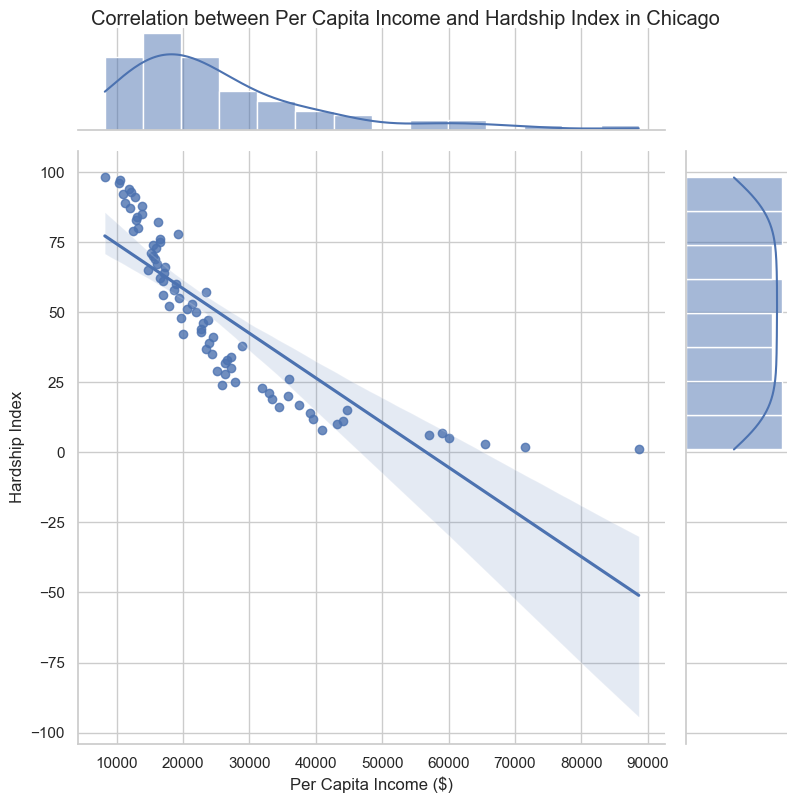

Pearson Correlation Coefficient: -0.8492


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the summary row for the whole city to keep the plot focused on community areas
df_clean = df.dropna(subset=['ca', 'hardship_index'])

# Create the scatter plot with a regression line
sns.set_theme(style="whitegrid")
plot = sns.jointplot(x='per_capita_income', y='hardship_index', data=df_clean, kind='reg', height=8)

# Add titles and labels
plot.set_axis_labels('Per Capita Income ($)', 'Hardship Index')
plt.suptitle('Correlation between Per Capita Income and Hardship Index in Chicago', y=1)

# Show the plot
plt.show()

# Calculate the correlation coefficient
correlation = df_clean['per_capita_income'].corr(df_clean['hardship_index'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

##### What does this mean?

+ **Strong Negative Correlation**: A value of −0.8491 indicates a strong negative relationship. On a scale from −1 to +1, values close to −1 show that as one variable increases, the other significantly decreases.

+ **Visual Trend**: In the scatter plot, we will see the data points forming a clear downward slope from the top-left to the bottom-right. This confirms that community areas with a higher `per_capita_income` tend to have a lower `hardship_index`.

+ **Socioeconomic Insight**: This makes intuitive sense. The Hardship Index is calculated using factors like poverty, unemployment, and lack of education. Areas with higher wealth (`per_capita_income`) naturally have lower scores in these categories, leading to a lower overall `hardship_index`.

### Conclusion: Socioeconomic Patterns in Chicago (2008–2012)

Our exploration of the 77 community areas in Chicago reveals a city with significant economic disparities. By combining database management with statistical visualization, we reached the following insights:

+ **The Wealth Gap**: We identified a elite group of neighborhoods, such as the Near North Side and Lincoln Park, where per capita income exceeds $70,000. In stark contrast, we found areas like Riverdale which face the highest levels of systemic challenge, reaching a maximum Hardship Index of 98.

+ **The Inverse Relationship**: The scatter plot and the Pearson Correlation Coefficient of approximately −0.85 provide mathematical proof of a strong negative correlation between income and hardship. As income rises, the multifaceted "hardship" (comprised of unemployment, crowded housing, and low education) drops precipitously.

+ **Data-Driven Methodology**: This project demonstrated how to effectively move data from a raw CSV format into a structured SQL database. We established a workflow that allows for rapid querying and seamless integration with Python’s visualization libraries like Seaborn.

---

### Final Thoughts

This analysis serves as a baseline for understanding the public health and economic landscape of Chicago. These indicators are not just numbers; they represent the daily lived experiences of the city's residents during that four-year period. For a data scientist, this highlights the importance of feature correlation—understanding how one metric (like income) can serve as a factor for a much more complex social reality (the Hardship Index).